# Spin-1/2 et Couplage de Moment Cinétique

**Référence :** Cohen-Tannoudji, Diu, Laloë — *Mécanique Quantique Tome 2*, Ch. IX et Ch. X

---

## Cadre théorique

### État de spin-1/2 (Règle R7.1)
$$|\chi\rangle = \cos\!\frac{\theta}{2}|{+}\rangle + e^{i\varphi}\sin\!\frac{\theta}{2}|{-}\rangle$$

Vecteur de Bloch : $\vec{n} = (\sin\theta\cos\varphi,\;\sin\theta\sin\varphi,\;\cos\theta)$, $|\vec{n}|=1$ pour un état pur.

### Opérateurs de spin (Règle R7.1)
$$\hat{S}_i = \frac{\hbar}{2}\sigma_i, \quad [\hat{S}_i,\hat{S}_j] = i\hbar\varepsilon_{ijk}\hat{S}_k, \quad \{\sigma_i,\sigma_j\} = 2\delta_{ij}\mathbb{1}$$

### Matrice densité (Règle R7.2)
$$\rho = \frac{1}{2}\!\left(\mathbb{1} + \vec{P}\cdot\vec{\sigma}\right), \quad \mathrm{Tr}(\rho^2) \leq 1 \;(\text{égalité : état pur})$$

### Coefficients de Clebsch-Gordan (Règle R8.2)
Pour $j_1=j_2=\tfrac{1}{2}$ : $|1,0\rangle = \frac{1}{\sqrt{2}}(|{+},{-}\rangle + |{-},{+}\rangle)$, $\;|0,0\rangle = \frac{1}{\sqrt{2}}(|{+},{-}\rangle - |{-},{+}\rangle)$

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[2]))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from quantum_simulation.core.spin import SpinHalf, SpinOperators, SpinDensityMatrix
from quantum_simulation.core.angular_momentum import ClebschGordan, AngularMomentumCoupling
from quantum_simulation.validation.tome2_invariants import SpinValidator, ClebschGordanValidator
from quantum_simulation.utils.config_loader import load_config

config = load_config()
hbar = config['physical_constants']['hbar']

print(f'ℏ = {hbar:.6e} J·s')
print('Modules chargés : spin, moment cinétique, validators Tome 2')


ℏ = 1.054572e-34 J·s
Modules chargés : spin, moment cinétique, validators Tome 2


## 1. États de spin-1/2 et vecteur de Bloch

L'état le plus général d'un spin-1/2 est paramétrisé par deux angles sphériques
$\theta \in [0,\pi]$ et $\varphi \in [0,2\pi)$.
Le **vecteur de Bloch** $\vec{n} = \langle\vec{\sigma}\rangle$ est de longueur 1 pour un état pur.

In [2]:
# États de base
spin_up   = SpinHalf.spin_up(hbar)
spin_down = SpinHalf.spin_down(hbar)

print('État |+⟩ :')
print(f'  composantes   : {spin_up.coefficients}')
print(f'  norme         : {spin_up.norm():.8f}')
print(f'  vecteur Bloch : {spin_up.to_bloch_vector()}  (attendu: [0, 0, 1])')

print()
print('État |-⟩ :')
print(f'  composantes   : {spin_down.coefficients}')
print(f'  vecteur Bloch : {spin_down.to_bloch_vector()}  (attendu: [0, 0, -1])')

# État général |χ⟩ (θ=π/3, φ=π/4)
theta, phi = np.pi / 3, np.pi / 4
chi = SpinHalf.from_bloch_angles(theta, phi, hbar)
bv  = chi.to_bloch_vector()

bv_th = np.array([np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)])
err   = np.max(np.abs(bv - bv_th))

print()
print(f'État |χ⟩  (θ={theta:.4f} rad, φ={phi:.4f} rad) :')
print(f'  Bloch calculé  : ({bv[0]:+.6f}, {bv[1]:+.6f}, {bv[2]:+.6f})')
print(f'  Bloch théorique: ({bv_th[0]:+.6f}, {bv_th[1]:+.6f}, {bv_th[2]:+.6f})')
print(f"  {'✓' if err < 1e-10 else '✗'} Accord vecteur de Bloch  (erreur max = {err:.2e})")
print(f'  |n| = {np.linalg.norm(bv):.8f}  (état pur → 1)')


État |+⟩ :
  composantes   : [1.+0.j 0.+0.j]
  norme         : 1.00000000
  vecteur Bloch : [0. 0. 1.]  (attendu: [0, 0, 1])

État |-⟩ :
  composantes   : [0.+0.j 1.+0.j]
  vecteur Bloch : [ 0.  0. -1.]  (attendu: [0, 0, -1])

État |χ⟩  (θ=1.0472 rad, φ=0.7854 rad) :
  Bloch calculé  : (+0.612372, +0.612372, +0.500000)
  Bloch théorique: (+0.612372, +0.612372, +0.500000)
  ✓ Accord vecteur de Bloch  (erreur max = 1.11e-16)
  |n| = 1.00000000  (état pur → 1)


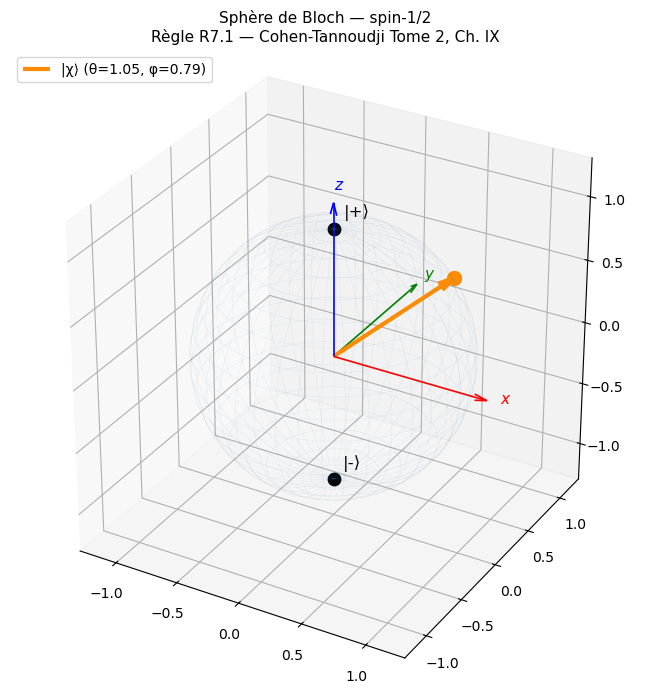

Figure sauvegardée → results/05_bloch_sphere.png


In [3]:
# Visualisation sur la sphère de Bloch
fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='3d')

# Sphère de Bloch (wireframe)
u_s = np.linspace(0, 2*np.pi, 40)
v_s = np.linspace(0, np.pi,   20)
xs  = np.outer(np.cos(u_s), np.sin(v_s))
ys  = np.outer(np.sin(u_s), np.sin(v_s))
zs  = np.outer(np.ones_like(u_s), np.cos(v_s))
ax.plot_wireframe(xs, ys, zs, alpha=0.08, color='steelblue', linewidth=0.5)

# Axes
for vec, label, col in [([1,0,0],'x','red'), ([0,1,0],'y','green'), ([0,0,1],'z','blue')]:
    ax.quiver(0,0,0,*vec, length=1.2, color=col, linewidth=1.2, arrow_length_ratio=0.08)
    ax.text(*(np.array(vec)*1.3), f'${label}$', fontsize=11, color=col)

# Pôles
for sp, label in [(spin_up,'|+⟩'), (spin_down,'|-⟩')]:
    bv2 = sp.to_bloch_vector()
    ax.scatter(*bv2, s=80, zorder=5, color='black')
    ax.text(bv2[0]+0.05, bv2[1]+0.05, bv2[2]+0.08, label, fontsize=12)

# État |χ⟩
bv = chi.to_bloch_vector()
ax.quiver(0,0,0,*bv, color='darkorange', linewidth=3, arrow_length_ratio=0.12, label=f'|χ⟩ (θ={theta:.2f}, φ={phi:.2f})')
ax.scatter(*bv, s=100, color='darkorange', zorder=10)

ax.set_xlim([-1.3, 1.3]); ax.set_ylim([-1.3, 1.3]); ax.set_zlim([-1.3, 1.3])
ax.set_box_aspect([1,1,1])
ax.set_title('Sphère de Bloch — spin-1/2\nRègle R7.1 — Cohen-Tannoudji Tome 2, Ch. IX', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('../../results/05_bloch_sphere.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → results/05_bloch_sphere.png')


## 2. Opérateurs de spin — Relations de commutation et d'anticommutation

$$[\hat{S}_x, \hat{S}_y] = i\hbar\hat{S}_z, \quad[\hat{S}_y, \hat{S}_z] = i\hbar\hat{S}_x, \quad[\hat{S}_z, \hat{S}_x] = i\hbar\hat{S}_y$$

$$\{\sigma_i, \sigma_j\} = 2\delta_{ij}\mathbb{1}$$

Règle de Heisenberg généralisée pour le spin :
$$\Delta S_x \cdot \Delta S_y \geq \frac{\hbar}{2}|\langle\hat{S}_z\rangle|$$

In [4]:
ops = SpinOperators(hbar)

# Validation algébrique
comm_ok  = ops.validate_commutation_relations()
anti_ok  = ops.validate_pauli_anticommutation()

print('VALIDATION ALGÉBRIQUE DES OPÉRATEURS DE SPIN')
print('-' * 55)
print(f"  {'✓' if comm_ok  else '✗'} Relations de commutation [Si,Sj] = iℏ εijk Sk")
print(f"  {'✓' if anti_ok  else '✗'} Anticommutation de Pauli  {{σi,σj}} = 2δij 𝟙")

# Valeurs propres de S²
S_sq = ops.S_squared
eigvals_sq = np.linalg.eigvalsh(S_sq)
s_s1 = 0.5 * (0.5 + 1) * hbar**2
print(f'  S² vp = {eigvals_sq[0]:.4e} J²  (attendu : s(s+1)ℏ² = {s_s1:.4e} J²)')
ok_sq = np.allclose(eigvals_sq, s_s1, rtol=1e-8)
print(f"  {'✓' if ok_sq else '✗'} Valeurs propres de Ŝ² = s(s+1)ℏ² = (3/4)ℏ²")

# Espérances et incertitudes sur |χ⟩
ex = ops.expectation_value(chi, 'x')
ey = ops.expectation_value(chi, 'y')
ez = ops.expectation_value(chi, 'z')
dx = ops.uncertainty(chi, 'x')
dy = ops.uncertainty(chi, 'y')

print()
print('OBSERVABLES SUR |χ⟩ (θ=π/3, φ=π/4) :')
print(f'  ⟨Sx⟩ = {ex:+.4e} J·s⁻¹,  ΔSx = {dx:.4e}')
print(f'  ⟨Sy⟩ = {ey:+.4e} J·s⁻¹,  ΔSy = {dy:.4e}')
print(f'  ⟨Sz⟩ = {ez:+.4e} J·s⁻¹')
product = dx * dy
bound   = abs(ez) * hbar / 2
print(f'  ΔSx·ΔSy = {product:.4e}  ≥  |⟨Sz⟩|ℏ/2 = {bound:.4e}')
print(f"  {'✓' if product >= bound - 1e-25 else '✗'} Inégalité de Heisenberg pour le spin")


VALIDATION ALGÉBRIQUE DES OPÉRATEURS DE SPIN
-------------------------------------------------------
  ✓ Relations de commutation [Si,Sj] = iℏ εijk Sk
  ✓ Anticommutation de Pauli  {σi,σj} = 2δij 𝟙
  S² vp = 8.3409e-69 J²  (attendu : s(s+1)ℏ² = 8.3409e-69 J²)
  ✓ Valeurs propres de Ŝ² = s(s+1)ℏ² = (3/4)ℏ²

OBSERVABLES SUR |χ⟩ (θ=π/3, φ=π/4) :
  ⟨Sx⟩ = +3.2290e-35 J·s⁻¹,  ΔSx = 4.1686e-35
  ⟨Sy⟩ = +3.2290e-35 J·s⁻¹,  ΔSy = 4.1686e-35
  ⟨Sz⟩ = +2.6364e-35 J·s⁻¹
  ΔSx·ΔSy = 1.7377e-69  ≥  |⟨Sz⟩|ℏ/2 = 1.3902e-69
  ✓ Inégalité de Heisenberg pour le spin


## 3. Matrice densité de spin (Règle R7.2)

Pour un état pur $|\chi\rangle$, la matrice densité est :
$$\rho = |\chi\rangle\langle\chi| = \frac{1}{2}(\mathbb{1} + \vec{P}\cdot\vec{\sigma}), \quad \vec{P} = \langle\vec{\sigma}\rangle$$

**Propriétés** : hermitique, $\mathrm{Tr}(\rho)=1$, définie positive, $\mathrm{Tr}(\rho^2) = 1$ (état pur).

In [5]:
# Matrice densité de l'état pur |χ⟩
rho = SpinDensityMatrix.from_pure_state(chi)
val = rho.validate()

print('MATRICE DENSITÉ DE |χ⟩')
print('-' * 40)
print(f"  {'✓' if val['is_hermitian']       else '✗'} Hermiticité  ρ† = ρ")
print(f"  {'✓' if val['trace_one']           else '✗'} Trace        Tr(ρ) = 1")
print(f"  {'✓' if val['positive_semidefinite'] else '✗'} Semi-définie positive")

purity = rho.purity()
bv_rho = rho.bloch_vector()
print(f'  Pureté Tr(ρ²) = {purity:.8f}  (état pur → 1)')
print(f'  Vecteur Bloch via ρ : ({bv_rho[0]:+.6f}, {bv_rho[1]:+.6f}, {bv_rho[2]:+.6f})')
print(f'  Via to_bloch_vector : ({bv[0]:+.6f}, {bv[1]:+.6f}, {bv[2]:+.6f})')
bv_err = np.max(np.abs(bv_rho - bv))
print(f"  {'✓' if bv_err < 1e-10 else '✗'} Cohérence  Tr(ρ σi) = ⟨σi⟩  (erreur = {bv_err:.2e})")

# Mélange : 50% |+⟩, 50% |-⟩
rho_mixed = SpinDensityMatrix.from_bloch_vector(np.array([0.0, 0.0, 0.0]))
print()
print('ÉTAT MIXTE 50/50 (vecteur de Bloch nul) :')
val_m = rho_mixed.validate()
print(f"  {'✓' if val_m['is_hermitian']        else '✗'} Hermiticité")
print(f"  {'✓' if val_m['trace_one']            else '✗'} Trace = 1")
print(f'  Pureté Tr(ρ²) = {rho_mixed.purity():.6f}  (état mixte → 1/2)')


MATRICE DENSITÉ DE |χ⟩
----------------------------------------
  ✓ Hermiticité  ρ† = ρ
  ✓ Trace        Tr(ρ) = 1
  ✓ Semi-définie positive
  Pureté Tr(ρ²) = 1.00000000  (état pur → 1)
  Vecteur Bloch via ρ : (+0.612372, +0.612372, +0.500000)
  Via to_bloch_vector : (+0.612372, +0.612372, +0.500000)
  ✓ Cohérence  Tr(ρ σi) = ⟨σi⟩  (erreur = 0.00e+00)

ÉTAT MIXTE 50/50 (vecteur de Bloch nul) :
  ✓ Hermiticité
  ✓ Trace = 1
  Pureté Tr(ρ²) = 0.500000  (état mixte → 1/2)


## 4. Coefficients de Clebsch-Gordan pour $j_1 = j_2 = \tfrac{1}{2}$ (Règle R8.2)

La table de CG (convention de Condon-Shortley) est une matrice **unitaire** de changement de base :

$$\{|+,+\rangle,\;|+,-\rangle,\;|-,+\rangle,\;|-,-\rangle\} \;\longrightarrow\; \{|1,1\rangle,\;|1,0\rangle,\;|0,0\rangle,\;|1,-1\rangle\}$$

In [6]:
# Table de Clebsch-Gordan pour j1=j2=1/2
table = ClebschGordan.two_spins_half_table()

print('TABLE DE CLEBSCH-GORDAN  j₁=j₂=1/2  (4×4)')
print('Colonnes : |m₁,m₂⟩ ∈ {|+,+⟩, |+,-⟩, |-,+⟩, |-,-⟩}')
print('Lignes   : |J,M⟩   ∈ {|1,+1⟩, |1,0⟩, |1,-1⟩, |0,0⟩}')
print()
labels_jm = ['|1,+1⟩', '|1, 0⟩', '|1,-1⟩', '|0, 0⟩']
for i, row in enumerate(table):
    print(f'  {labels_jm[i]} : {np.array2string(row, precision=6, suppress_small=True)}')

# Validation : unitarité et coefficients connus
cg_val  = ClebschGordanValidator()
res_uni = cg_val.unitarity(0.5, 0.5)
res_kno = cg_val.known_two_spin_half()

print()
print('VALIDATION')
print('-' * 50)
print(f"  {'✓' if res_uni['is_unitary'] else '✗'} Unitarité U†U = 𝟙  (erreur max = {res_uni['max_error']:.2e})")
print(f"  {'✓' if res_kno['all_correct'] else '✗'} Coefficients analytiques connus  (erreur max = {res_kno['max_error']:.2e})")
if res_kno.get('errors'):
    for err_info in res_kno['errors']:
        print(f'    ✗ {err_info}')

# Coefficient individuel
coeff_10 = ClebschGordan.coefficient(0.5, 0.5, 0.5, -0.5, 1, 0)  # ⟨1/2,+1/2; 1/2,-1/2|1,0⟩ = 1/√2
print(f'  ⟨1/2,+1/2 ; 1/2,-1/2|1,0⟩ = {coeff_10:.6f}  (attendu: {1/np.sqrt(2):.6f})')
coeff_00 = ClebschGordan.coefficient(0.5, 0.5, 0.5, -0.5, 0, 0)  # ⟨1/2,+1/2; 1/2,-1/2|0,0⟩ = 1/√2
print(f'  ⟨1/2,+1/2 ; 1/2,-1/2|0,0⟩ = {coeff_00:.6f}  (attendu: {1/np.sqrt(2):.6f})')


TABLE DE CLEBSCH-GORDAN  j₁=j₂=1/2  (4×4)
Colonnes : |m₁,m₂⟩ ∈ {|+,+⟩, |+,-⟩, |-,+⟩, |-,-⟩}
Lignes   : |J,M⟩   ∈ {|1,+1⟩, |1,0⟩, |1,-1⟩, |0,0⟩}

  |1,+1⟩ : [1. 0. 0. 0.]
  |1, 0⟩ : [0.       0.707107 0.707107 0.      ]
  |1,-1⟩ : [0. 0. 0. 1.]
  |0, 0⟩ : [ 0.        0.707107 -0.707107  0.      ]

VALIDATION
--------------------------------------------------
  ✓ Unitarité U†U = 𝟙  (erreur max = 3.33e-16)
  ✓ Coefficients analytiques connus  (erreur max = 2.22e-16)
  ⟨1/2,+1/2 ; 1/2,-1/2|1,0⟩ = 0.707107  (attendu: 0.707107)
  ⟨1/2,+1/2 ; 1/2,-1/2|0,0⟩ = 0.707107  (attendu: 0.707107)


## 5. Couplage $\hat{L}\cdot\hat{S}$ — facteur de Landé $g_J$

Pour les niveaux $n=2$ de l'hydrogène ($l=1$, $s=1/2$) :

$$\langle\hat{L}\cdot\hat{S}\rangle = \frac{\hbar^2}{2}[j(j+1) - l(l+1) - s(s+1)]$$

$$g_J = 1 + \frac{J(J+1) + S(S+1) - L(L+1)}{2J(J+1)}$$

|Niveau|$j$|$\langle L\cdot S\rangle$|$g_J$|
|---|---|---|---|
|$2p_{1/2}$|$1/2$|$-\hbar^2$|$2/3$|
|$2p_{3/2}$|$3/2$|$+\hbar^2/2$|$4/3$|

In [7]:
coupling_2p = AngularMomentumCoupling(1, 0.5)  # L=1, S=1/2

# 2p₁/₂ : j=1/2
ls_12   = coupling_2p.spin_orbit_matrix_element(n=2, l=1, j=0.5, hbar=hbar)
g_12    = coupling_2p.lande_g_factor(1, 0.5, 0.5)
ls_12_th = hbar**2 / 2 * (0.5*1.5 - 1*2 - 0.5*1.5)  # = -hbar^2

# 2p₃/₂ : j=3/2
ls_32   = coupling_2p.spin_orbit_matrix_element(n=2, l=1, j=1.5, hbar=hbar)
g_32    = coupling_2p.lande_g_factor(1, 0.5, 1.5)
ls_32_th = hbar**2 / 2 * (1.5*2.5 - 1*2 - 0.5*1.5)  # = +hbar^2/2

print("COUPLAGE SPIN-ORBITE L·S (niveaux 2p de l'hydrogène)")
print('-' * 65)
print(f'  2p₁/₂ (j=1/2) :  ⟨L·S⟩ = {ls_12:.4e} J²  (th: {ls_12_th:.4e})')
ls_ok12 = abs(ls_12 - ls_12_th) < 1e-45 * abs(ls_12_th) + 1e-80
print(f"  {'✓' if abs(ls_12 - ls_12_th) < 1e-65 + abs(ls_12_th)*1e-6 else '✗'} Accord 2p₁/₂")
print(f'  2p₃/₂ (j=3/2) :  ⟨L·S⟩ = {ls_32:.4e} J²  (th: {ls_32_th:.4e})')
print(f"  {'✓' if abs(ls_32 - ls_32_th) < 1e-65 + abs(ls_32_th)*1e-6 else '✗'} Accord 2p₃/₂")

print()
print('FACTEUR DE LANDÉ g_J')
print(f'  2p₁/₂ : g_J = {g_12:.6f}  (attendu : 2/3 = {2/3:.6f})  {"✓" if abs(g_12 - 2/3) < 1e-6 else "✗"}')
print(f'  2p₃/₂ : g_J = {g_32:.6f}  (attendu : 4/3 = {4/3:.6f})  {"✓" if abs(g_32 - 4/3) < 1e-6 else "✗"}')

# Matrice de moment angulaire total (J=1)
J_sq, J_z = coupling_2p.total_angular_momentum_matrix(J=1)
print()
print(f'  Matrice J² (J=1) : vp = {np.sort(np.linalg.eigvalsh(J_sq.real))}')
print(f'  Attendu : J(J+1)ℏ² = {1*2*hbar**2:.4e}  (×3 fois)')


COUPLAGE SPIN-ORBITE L·S (niveaux 2p de l'hydrogène)
-----------------------------------------------------------------
  2p₁/₂ (j=1/2) :  ⟨L·S⟩ = -1.1121e-68 J²  (th: -1.1121e-68)
  ✓ Accord 2p₁/₂
  2p₃/₂ (j=3/2) :  ⟨L·S⟩ = 5.5606e-69 J²  (th: 5.5606e-69)
  ✓ Accord 2p₃/₂

FACTEUR DE LANDÉ g_J
  2p₁/₂ : g_J = 0.666667  (attendu : 2/3 = 0.666667)  ✓
  2p₃/₂ : g_J = 1.333333  (attendu : 4/3 = 1.333333)  ✓

  Matrice J² (J=1) : vp = [2. 2. 2.]
  Attendu : J(J+1)ℏ² = 2.2242e-68  (×3 fois)


## 6. Validation finale — résumé

In [8]:
sv  = SpinValidator()
cgv = ClebschGordanValidator()

print('BILAN DE VALIDATION — Tome 2 Chapitre IX-X')
print('=' * 55)

# Spin
ok1 = sv.bloch_vector_bound(chi)
ok2 = sv.pauli_anticommutation(ops)
ok3 = sv.spin_squared_eigenvalue(chi)
val_dm = sv.density_matrix_valid(rho)
ok4 = val_dm['is_hermitian'] and val_dm['trace_one'] and val_dm['positive_semidefinite']

print(f"  {'✓' if ok1 else '✗'} Vecteur de Bloch |n| = 1  (état pur)")
print(f"  {'✓' if ok2 else '✗'} Anticommutation de Pauli {{σi,σj}} = 2δij")
print(f"  {'✓' if ok3 else '✗'} Valeur propre S² = s(s+1)ℏ²")
print(f"  {'✓' if ok4 else '✗'} Matrice densité valide (hermitique, Tr=1, définie+)")

# CG
ok5 = cgv.unitarity(0.5, 0.5)['is_unitary']
ok6 = cgv.known_two_spin_half()['all_correct']
ok7 = cgv.selection_rule_M(0.5, 0.5)
ok8 = cgv.triangle_rule(0.5, 0.5, 0)   # J=0 autorisé
ok9 = not cgv.triangle_rule(0.5, 0.5, 2)  # J=2 interdit

print(f"  {'✓' if ok5 else '✗'} Unitarité table CG j₁=j₂=1/2")
print(f"  {'✓' if ok6 else '✗'} Coefficients CG analytiques")
print(f"  {'✓' if ok7 else '✗'} Règle de sélection M = m₁+m₂")
print(f"  {'✓' if ok8 else '✗'} Règle triangulaire : J=0 autorisé  (|j₁-j₂|≤J≤j₁+j₂)")
print(f"  {'✓' if ok9 else '✗'} Règle triangulaire : J=2 interdit")

all_ok = all([ok1,ok2,ok3,ok4,ok5,ok6,ok7,ok8,ok9])
print()
print(f"{'✓ Toutes les validations réussies !' if all_ok else '✗ Certaines validations ont échoué'}")


BILAN DE VALIDATION — Tome 2 Chapitre IX-X
  ✓ Vecteur de Bloch |n| = 1  (état pur)
  ✓ Anticommutation de Pauli {σi,σj} = 2δij
  ✓ Valeur propre S² = s(s+1)ℏ²
  ✓ Matrice densité valide (hermitique, Tr=1, définie+)
  ✓ Unitarité table CG j₁=j₂=1/2
  ✓ Coefficients CG analytiques
  ✓ Règle de sélection M = m₁+m₂
  ✓ Règle triangulaire : J=0 autorisé  (|j₁-j₂|≤J≤j₁+j₂)
  ✓ Règle triangulaire : J=2 interdit

✓ Toutes les validations réussies !
